In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### Qual filme você recomendaria para uma pessoa que não conhece?


In [5]:

df = pd.read_csv("../data/processed/imdb_oscar.csv")

# índice multiplicativo
df["recommend_index"] = df["IMDB_Rating"] * np.log1p(df["No_of_Votes"])

# ordenar do maior pro menor
df_best = df.sort_values("recommend_index", ascending=False)

# top 5 recomendados
print(df_best[["film", "IMDB_Rating", "No_of_Votes", "oscar_wins"]].head(5))


                                            film  IMDB_Rating  No_of_Votes  \
1                                The Dark Knight          9.0      2303232   
0                                  The Godfather          9.2      1620367   
5                                   Pulp Fiction          8.9      1826188   
7                                      Inception          8.8      2067042   
4  The Lord of the Rings: The Return of the King          8.9      1642758   

   oscar_wins  
1           2  
0           3  
5           1  
7           4  
4          11  


                count          mean           std      min          25%  \
competiu_oscar                                                            
0               283.0  4.095295e+07  9.686043e+07   1305.0   1790782.50   
1               430.0  1.033504e+08  1.193717e+08  10177.0  23352172.75   

                       50%          75%          max  
competiu_oscar                                        
0                6167817.0   39538495.0  936662225.0  
1               56517172.5  142337949.0  858373000.0  


/tmp/ipykernel_15017/3080106277.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


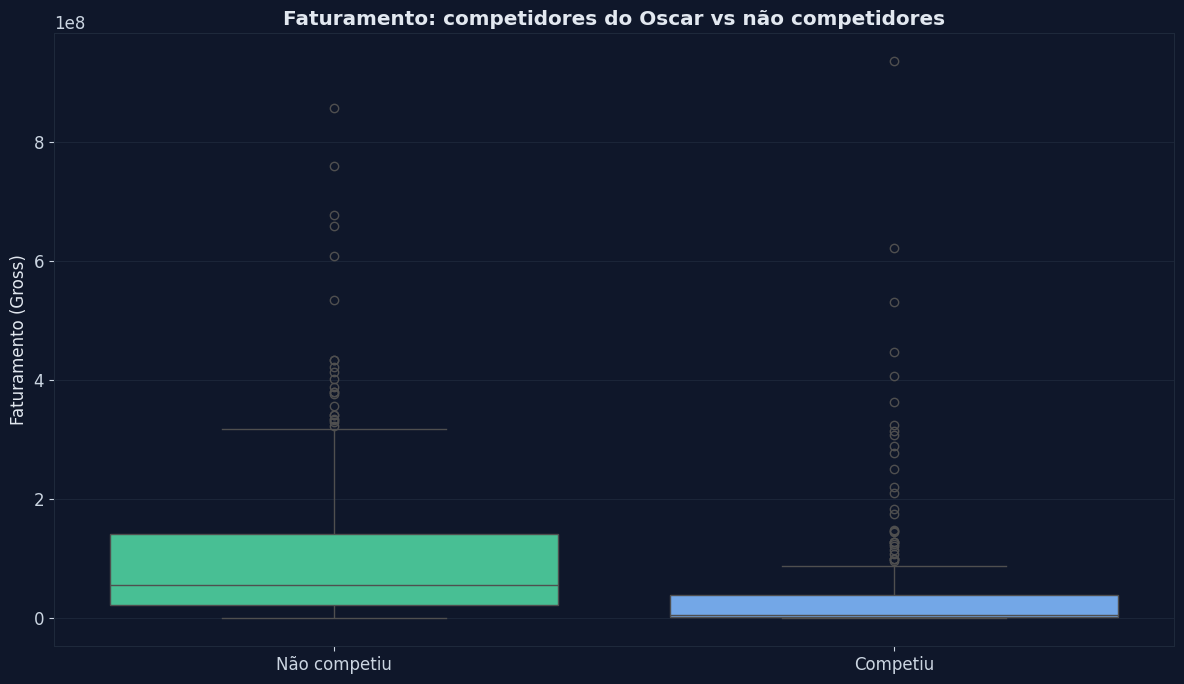

T-test: t=nan, p=nan


/home/isadora/movie_analysis/venv/lib/python3.12/site-packages/scipy/_lib/deprecation.py:234: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  return f(*args, **kwargs)


In [8]:

# garantir Gross numérico
df["Gross"] = pd.to_numeric(df["Gross"], errors="coerce")

# flag: competiu ou não competiu
df["competiu_oscar"] = (df["oscar_nominations"] > 0).astype(int)

# resumo estatístico
print(df.groupby("competiu_oscar")["Gross"].describe())

df["competiu_oscar"] = df["competiu_oscar"].astype(str)

sns.boxplot(
    data=df, x="competiu_oscar", y="Gross",
    palette={"0":"#60a5fa", "1":"#34d399"}
)
plt.xticks([0,1], ["Não competiu", "Competiu"])

plt.ylabel("Faturamento (Gross)")
plt.xlabel("")
plt.title("Faturamento: competidores do Oscar vs não competidores")
plt.tight_layout()
plt.show()

# teste estatístico: t-test
from scipy.stats import ttest_ind
grp1 = df.loc[df["competiu_oscar"]==1, "Gross"].dropna()
grp0 = df.loc[df["competiu_oscar"]==0, "Gross"].dropna()
t, p = ttest_ind(grp1, grp0, equal_var=False)
print(f"T-test: t={t:.2f}, p={p:.4f}")
